Monthly average of CO2 and CH4 time-series data, as well as the global temperature data, used for this project is from NOAA Global Monitoring Laboratory "https://gml.noaa.gov/data/data.php"

Understanding the relationship between greenhouse gases and temperature is important because it helps us predict the future changes in the climate. In this project, I study time-series data of CO2 (Carbon dioxide) and CH4 (Methane) concentrations obtained from Baltic Sea monitoring station. The goal is to find long term trends and seasonal changes from the data and to  calculate the correlation between the two gases. Machine learning is used to forecast CO2 concentration and test wether CH4 time-series data can be used to predict CO2 short term changes. Finally, I analyze the relationship between CO2 gas concentration and temperature trends in a local area to look for correlations between these two.

# Data processing

In [1]:
#Imported libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xarray as xr
import cartopy.crs as ccrs
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.arima.model import ARIMA

# NOAA GML custom modules
from ccgvu import ccg_dates  # Date utilities
from ccgvu import ccg_filter  # Data filtering and curve fitting

In [2]:
#Read Ch4 and CO2 emission data from baltic sea
ch4_filename = "ch4_baltic.txt"
co2_filename = "co2_baltic.txt"
ch4_data = pd.read_table(ch4_filename, header=None, sep = r'\s+', skiprows=53)
co2_data = pd.read_table(co2_filename, header=None, sep = r'\s+', skiprows=53)

In [3]:
#Read feature names from a file
def read_header_file(filename):
    with open(filename, "r") as f:
        for line in f:
            if line.startswith("#") and "data_fields:" in line:
                cols = line.strip().split("data_fields:")[1].strip().split()
                break
    return cols

In [4]:
#Add the names to dataframe
ch4_data.columns = read_header_file(ch4_filename)
co2_data.columns = read_header_file(co2_filename)

In [5]:
#Exclude location of measurement from each row because data is only from baltic sea
ch4_data = ch4_data.iloc[: , 1:]
co2_data = co2_data.iloc[: , 1:]


In [6]:
#Add date to each dataset
ch4_data["date"] = pd.to_datetime(dict(year=ch4_data.year, month=ch4_data.month, day = 1))
co2_data["date"] = pd.to_datetime(dict(year=co2_data.year, month=co2_data.month, day = 1))

In [7]:
# combine CO2 and CH4 datasets
data = co2_data.merge(ch4_data, on=["year", "month", "date"], how="inner")
data = data.sort_values("date")
data = data.iloc[:, [3, 0, 1, 2, 4]]
data.columns = ["date", "year", "month", "co2", "ch4"]

In [8]:
display(data)

,date,year,month,co2,ch4
0,1992-09-01,1992,9,353.17,1846.87
1,1992-10-01,1992,10,359.98,1853.50
2,1992-11-01,1992,11,361.21,1850.97
3,1992-12-01,1992,12,360.48,1832.20
4,1993-01-01,1993,1,362.70,1828.41
...,...,...,...,...,...
208,2011-02-01,2011,2,400.03,1921.64
209,2011-03-01,2011,3,401.30,1918.01
210,2011-04-01,2011,4,397.96,1898.30
211,2011-05-01,2011,5,396.36,1895.60


In [9]:
#Add decimaltime to dataset for later use
data["decimaltime"] = data.apply(lambda row: row["year"] + row["month"]/12, axis=1)

# Data analysis

In [10]:
# Create filter object using NOAA GML's curve fitting class
def apply_ccg_filter(xp, yp):
    filt = ccg_filter.ccgFilter(
        xp,  
        yp, 
        shortterm=80,  
        longterm=667,    
        sampleinterval=0,
        numpolyterms=3,      
        numharmonics=4,     
        timezero=-1,         
        gap=0,          
        use_gain_factor=False, 
        debug=False         
    )

    # Interpolated time grid
    x0 = filt.xinterp
    
    # Extract components
    smooth = filt.getSmoothValue(x0)
    trend = filt.getTrendValue(x0)
    seasonal = smooth - trend  # seasonal component
    
    # Convert to datetime
    dates = [ccg_dates.datetimeFromDecimalDate(x) for x in x0]
    
    # Build DataFrame
    df = pd.DataFrame({
        "date": dates,
        f"smooth": smooth,
        f"trend": trend,
        f"seasonal": seasonal
    })
    
    return df

In [11]:
co2_df = apply_ccg_filter(data["decimaltime"], data["co2"])
ch4_df = apply_ccg_filter(data["decimaltime"], data["ch4"])

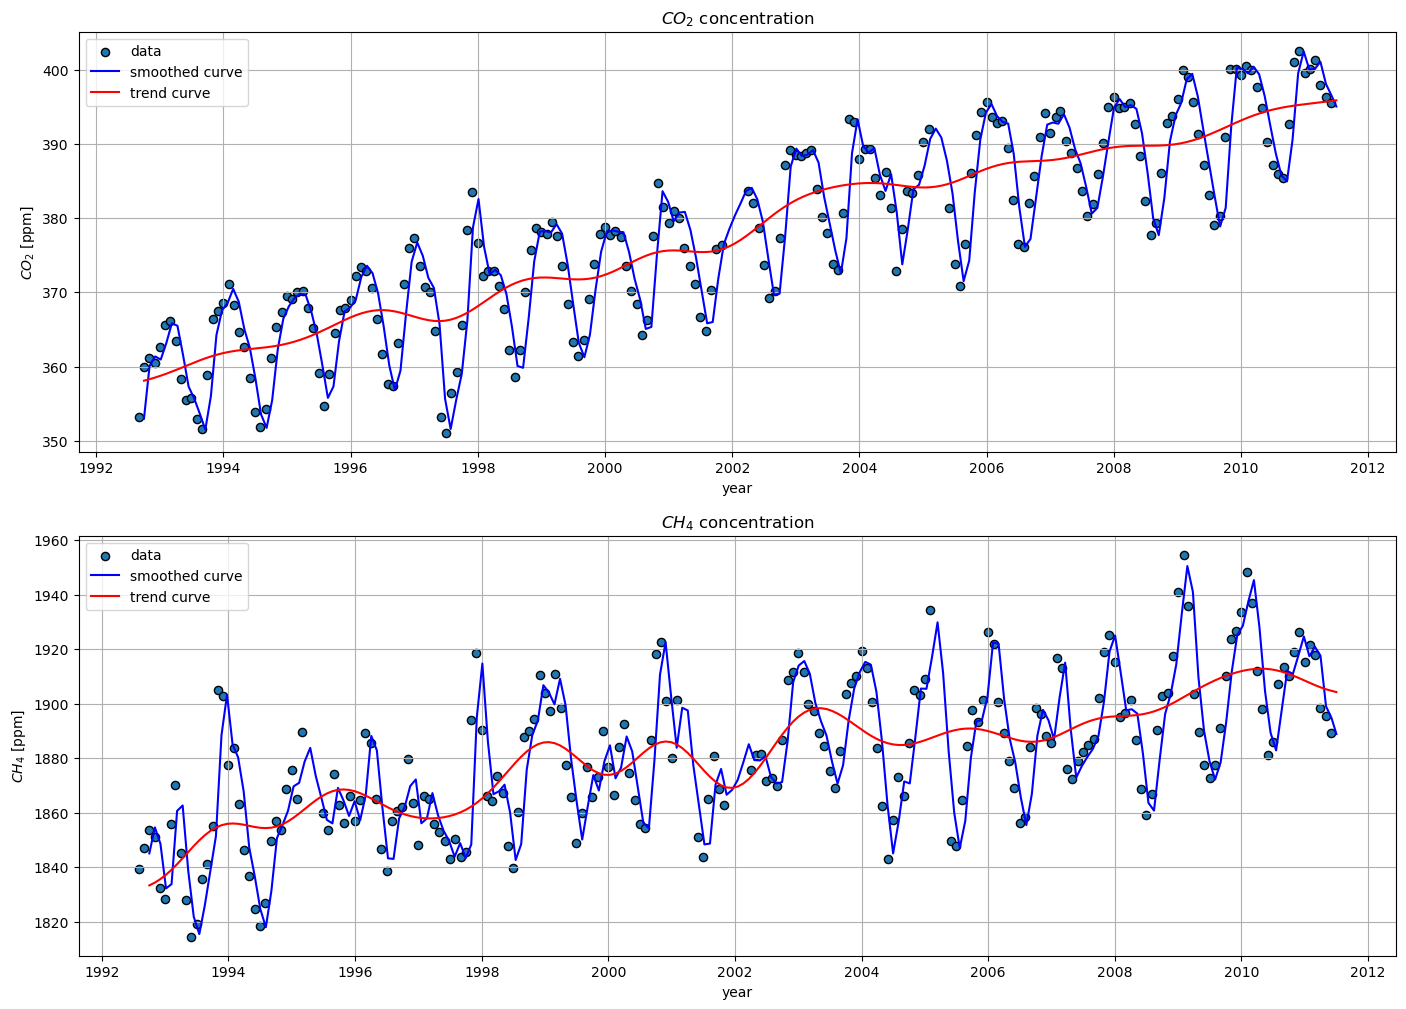

In [12]:
# Function fit and measured data fro CO2 and CH4
fig,ax = plt.subplots(2, figsize=(17,12))

ax[0].scatter(co2_data["date"], co2_data["value"], s=35, edgecolors= "black", label = "data")
ax[0].plot(co2_df["date"], co2_df["smooth"], c="blue", label= "smoothed curve")
ax[0].plot(co2_df["date"], co2_df["trend"], c="red", label = "trend curve")
ax[0].set_xlabel("year")
ax[0].set_ylabel("$CO_2$ [ppm]")
ax[0].set_title("$CO_2$ concentration")
ax[0].grid()
ax[0].legend()

ax[1].scatter(ch4_data["date"], ch4_data["value"], s=35, edgecolors= "black", label = "data")
ax[1].plot(ch4_df["date"], ch4_df["smooth"], c="blue", label = "smoothed curve")
ax[1].plot(ch4_df["date"], ch4_df["trend"], c="red", label = "trend curve")
ax[1].set_xlabel("year")
ax[1].set_ylabel("$CH_4$ [ppm]")
ax[1].set_title("$CH_4$ concentration")
ax[1].grid()
ax[1].legend()



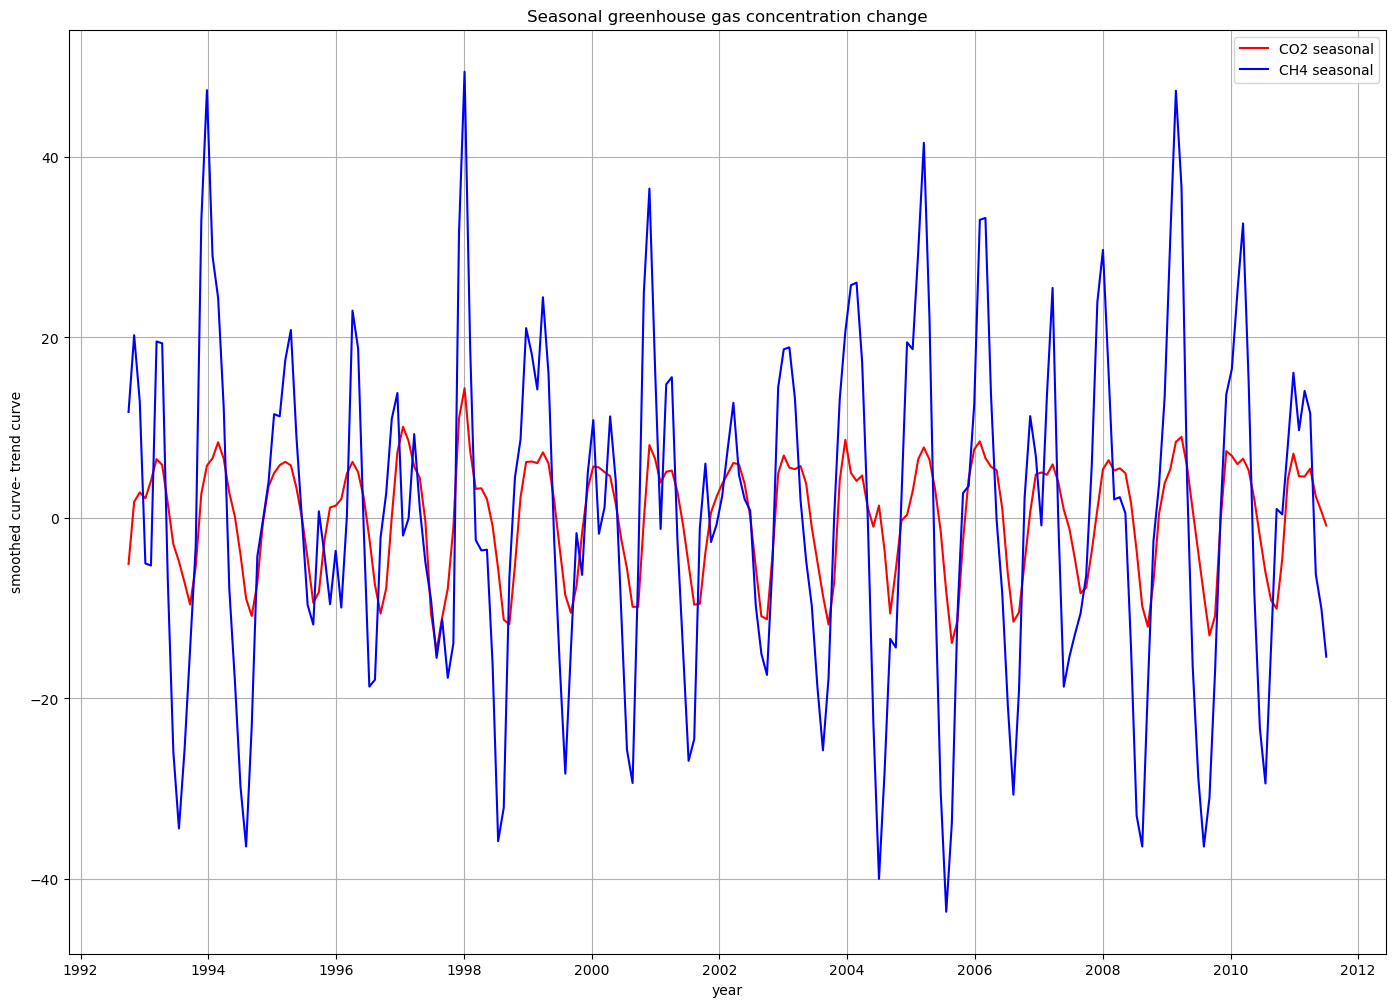

In [37]:
#Plot to compare seasonal change of CO2 and CH4 emission
plt.figure(figsize=(17,12))

plt.plot(co2_df["date"], co2_df["seasonal"], c="red", label="CO2 seasonal")
plt.plot(ch4_df["date"], ch4_df["seasonal"], c="blue", label = "CH4 seasonal")
plt.title("Seasonal greenhouse gas concentration change")
plt.xlabel("year")
plt.ylabel("smoothed curve- trend curve")
plt.grid()
plt.legend()

In [14]:
#Pearson correlation of smoothed, trend and seasonal data to find correlation of CO2 and Ch4 emissions
corr = co2_df["smooth"].corr(ch4_df["smooth"])
trend_corr = co2_df["trend"].corr(ch4_df["trend"])
seasonal_corr = co2_df["seasonal"].corr(ch4_df["seasonal"])
print(f"Smoothed data correlation: {corr:.3f}")
print(f"Trend correlation: {trend_corr:.3f}")
print(f"Seasonal correlation: {seasonal_corr:.3f}")

Smoothed data correlation: 0.829
Trend correlation: 0.943
Seasonal correlation: 0.736


# Machine learning

### CO2 emission forecasting with ARIMA model

In [15]:
# In this model the polynomial features are used as input features

#the number of features is the number of data points
t = np.arange(len(co2_df)).reshape(-1,1)
# Third degree polynomial is used
poly = PolynomialFeatures(degree=3, include_bias=False)
X = poly.fit_transform(t)

In [16]:
# input values for forecasting
t_future = np.arange(len(co2_df), len(co2_df)+36).reshape(-1,1)
X_future = poly.transform(t_future)

In [17]:
#Split the training and testing data to 80/20
train_split = int(len(X)*0.8)
train_split

172

In [18]:
# CO2 trend values are output features of the model
y_train = co2_df["trend"].iloc[:train_split]
y_test = co2_df["trend"].iloc[train_split:]

In [19]:
X_train = X[:train_split]
X_test = X[train_split:]

In [20]:
# model training
arima_model = ARIMA(endog=y_train.values, exog=X_train, trend="n", order=(1,1,1)).fit()

C:\Users\OMISTAJA\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\OMISTAJA\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [21]:
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  172
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 308.521
Date:                Sun, 08 Mar 2026   AIC                           -605.042
Time:                        16:49:28   BIC                           -586.192
Sample:                             0   HQIC                          -597.394
                                - 172                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.1831      1.020      0.179      0.858      -1.817       2.183
x2             0.0003      0.008      0.035      0.972      -0.015       0.015
x3         -1.604e-06      2e-05     -0.080      0.9

In [22]:
#Combining testing and training input features to get predicted output features
X_test_future = np.vstack([X_test, X_future])

y_all = arima_model.forecast(
    steps=len(y_test) + len(t_future),
    exog=X_test_future
)

y_pred = y_all[:len(y_test)]
y_future = y_all[len(y_test):]

In [23]:
# testing model accuracy with mae, rmse and r2
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.8525659169479698
RMSE: 0.9151768124068104
MAE: 0.8117890863363781


In [24]:
step = np.median(np.diff(co2_df["date"]))

#Converting input features back to original time
train_dates = co2_df["date"].iloc[:train_split]
test_dates = co2_df["date"].iloc[train_split:]
future_dates = pd.date_range(
    start=test_dates.iloc[-1],
    periods=len(t_future) + 1,
    freq="MS"
)[1:]

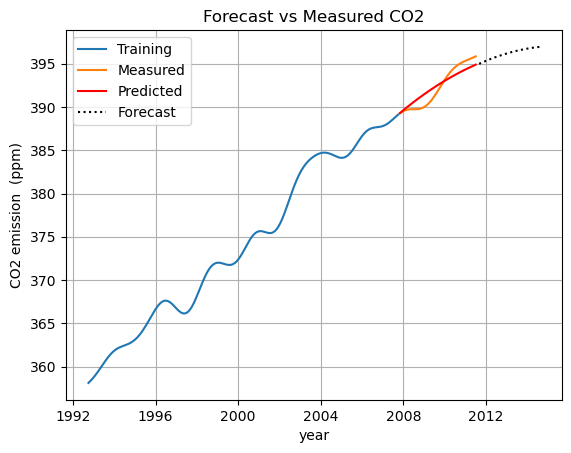

In [25]:
#plotting measured values vs model predicted values and forecast
plt.plot(train_dates, y_train, label="Training")
plt.plot(test_dates, y_test, label="Measured")
plt.plot(test_dates, y_pred, label="Predicted", color="red")
plt.plot(future_dates, y_future, label="Forecast", color="black", linestyle=":")
plt.ylabel("CO2 emission  (ppm)")
plt.xlabel("year")

plt.legend()
plt.grid()
plt.title("Forecast vs Measured CO2")
plt.show()

### Predicting CO2 emission from CH4 emission

In [26]:
#Machine learning model to predict CO2 emission from CH4 emission
 
X = ch4_df[["smooth", "trend"]]
y = co2_df["smooth"]


model = LinearRegression()
loo = LeaveOneOut()

y_true_arr = y.to_numpy().flatten()

y_true = []
y_pred = []

#I use standard Leave-one-out loop and remove inside the nearby data points of test data point
for train_idx, test_idx in loo.split(X):
        
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    #Building knn model with the reduced training set
    model.fit(X_train, y_train)
    #Making predictions
    pred = model.predict(X_test)
    
    #Appending predictions to list
    y_pred.append(pred[0])
    y_true.append(y_test.values[0])

y_pred = np.array(y_pred)
y_true = np.array(y_true)

In [27]:
# Accuracy
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R-squared: {r2:.3f}")

RMSE: 5.832
R-squared: 0.791


# Temperature analysis

In [28]:
# Open dataset which contains global temperature anomalies
path = "global_temperature.nc"
dataset = xr.open_dataset(path)
dataset

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 2088, z: 1, lat: 36, lon: 72)
Coordinates:
  * time     (time) datetime64[ns] 17kB 1850-01-01 1850-02-01 ... 2023-12-01
  * z        (z) float32 4B 0.0
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Data variables:
    anom     (time, z, lat, lon) float32 22MB ...
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA Merged Land Ocean Global Surface Te...
    summary:                         NOAAGlobalTemp is a merged land-ocean su...
    institution:                     DOC/NOAA/NESDIS/National Centers for Env...
    id:                               gov.noaa.ncdc:C00934 
    naming_authority:                 gov.noaa.ncei 
    ...                              ...
    time_coverage_duration:          P174Y0M
    references:                      Vose, R. S., et al., 2012: NOAAs merged ...
    climatology:                     Climatology is based on 1971-2000 monthl...
    acknowledgment:                  The NOAA Global Surface Temperature Data...
    date_modified:                   2024-01-08T20:02:41Z
    date_issued:                     2024-01-08T20:02:41Z

In [29]:
# Single date for global temperature anomaly visualization
desired_date = '2022-12-01'
data_for_desired_date = dataset.sel(time=desired_date)
data_for_desired_date

<xarray.Dataset> Size: 11kB
Dimensions:  (z: 1, lat: 36, lon: 72)
Coordinates:
  * z        (z) float32 4B 0.0
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
    time     datetime64[ns] 8B 2022-12-01
Data variables:
    anom     (z, lat, lon) float32 10kB ...
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA Merged Land Ocean Global Surface Te...
    summary:                         NOAAGlobalTemp is a merged land-ocean su...
    institution:                     DOC/NOAA/NESDIS/National Centers for Env...
    id:                               gov.noaa.ncdc:C00934 
    naming_authority:                 gov.noaa.ncei 
    ...                              ...
    time_coverage_duration:          P174Y0M
    references:                      Vose, R. S., et al., 2012: NOAAs merged ...
    climatology:                     Climatology is based on 1971-2000 monthl...
    acknowledgment:                  The NOAA Global Surface Temperature Data...
    date_modified:                   2024-01-08T20:02:41Z
    date_issued:                     2024-01-08T20:02:41Z

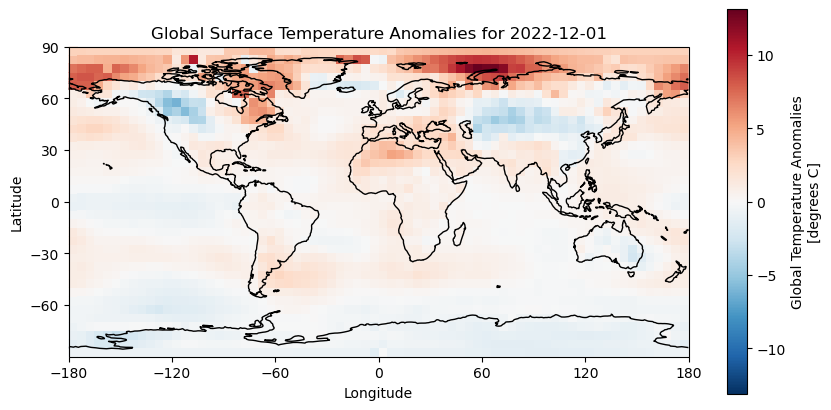

In [30]:
#Visualization of global temperature anomalies for single date
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
data_for_desired_date['anom'].plot(ax=ax,transform=ccrs.PlateCarree())
ax.coastlines()
plt.title(f'Global Surface Temperature Anomalies for {desired_date}')
ax.set_xticks(range(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(range(-60, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

In [31]:
# Create the DataFrame
temperature_data_nc = dataset.to_dataframe().reset_index()

# Preview the data
temperature_data_nc.head()

,time,z,lat,lon,anom
0,1850-01-01,0.0,-87.5,2.5,-0.177575
1,1850-01-01,0.0,-87.5,7.5,-0.177575
2,1850-01-01,0.0,-87.5,12.5,-0.177575
3,1850-01-01,0.0,-87.5,17.5,-0.177575
4,1850-01-01,0.0,-87.5,22.5,-0.177575


In [32]:
# Get temperature anomaly from local area (in this reserach the area is around baltic sea)
local_data = dataset.sel(lat=slice(50, 70), lon=slice(-60, 40))

local_data = local_data.to_dataframe().reset_index()

In [33]:
#Average the temperature anomalies around different coordinates
temp_mean_data = (local_data.groupby(local_data["time"])["anom"].mean().reset_index(name="avg_temp"))

In [34]:
#Restrict the data to smaller time interval
temp_mean_data = temp_mean_data[temp_mean_data["time"] >= "1980-09-01"]
temp_mean_data = temp_mean_data[temp_mean_data["time"] <= "2011-06-01"]
temp_mean_data = temp_mean_data.reset_index(drop=True)

In [35]:
#Rolling average for temperature anomaly to reduce noise
temp_mean_data["temp_smooth"] = (temp_mean_data["avg_temp"].rolling(window=60, center=True).mean())

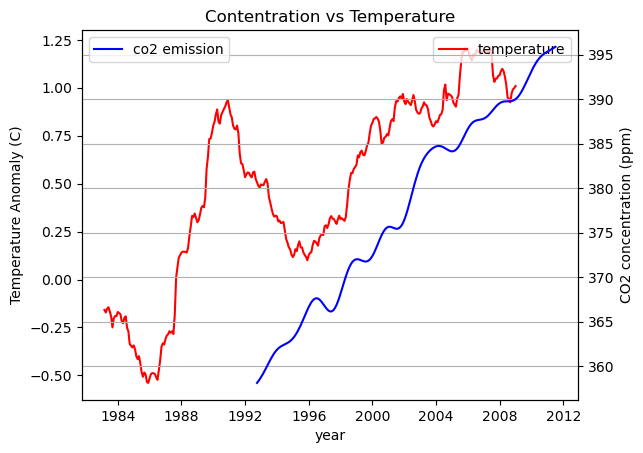

In [36]:
#Plot for comparing Temperature dependence on co2 emission
fig, ax1 = plt.subplots()

ax1.plot(temp_mean_data["time"], temp_mean_data["temp_smooth"], c = "red", label= "temperature")
ax1.set_ylabel("Temperature Anomaly (C)")
ax1.set_xlabel("year")

ax2 = ax1.twinx()
ax2.plot(co2_df["date"], co2_df["trend"], c = "blue", label = "co2 emission")
ax2.set_ylabel("CO2 concentration (ppm)")

plt.title("Contentration vs Temperature")
plt.grid()
ax1.legend(loc=1)
ax2.legend(loc=0)
plt.show()

# Conclusions

From the Pearson correlations we can see that CO2 and CH4 concentrations are highly correlated. The trend correlation was 0,94, this means that there are common long term factors which increase the emission of both CO2 and CH4 gases to environment. This could be because of energy production, agriculture and climate change. Seasonal data correlation was 0,73 which means that the seasonal changes, for exammple temperature change, affect the concentration of both gases in a similar way.

ARIMA model was used for CO2 forecasting. From the plot we can see that model can finds the general pattern in the concentration trend and performs reasonably well for short term predictions. This model still should not be used for longer term trends because it can not capture complex trends and the climate policies can change the trend in the future.

Because the two greenhouse gases are correlated we can use machine learning to predict the trend of one gas from another. Using leave-one-out regression the model got an accuracy of 0,79 which means that there is a reasonable accuracy to predict the changes of CO2 in the environment by CH4 concentrations. This analysis is limited by the size of dataset and the use of simple machine learning methods. But overall this project shows that there are clear correlations between greenhouse gases and we can use models to predict their behaviours.

The CO2 concentration and Temperature figure shows the relationship of the two over time in a local area around the Baltic Sea. The CO₂ concentration shows a clear long-term increasing trend, while the global temperature anomaly also shows an overall increase with signicicant short-term changes. It is still clear that the long-term temperature trend is upward which is is also true for CO2 concentration. It is important to note that this does not imply causality but only strong correlation.
